## Importación de Librerías

In [ ]:
#Tratamiento de datos
import pandas as pd
#Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

Vamos a tratar las columnas de fecha como tipo de dato `datetime`

In [3]:
df = pd.read_csv('../data/raw/autorenew.csv', parse_dates=['dateCrawled', 'dateCreated', 'lastSeen']) 

## Análisis Preliminar

In [4]:
df.sample(5)

,dateCrawled,name,seller,offerType,price,vehicleType,yearOfRegistration,gearbox,powerCV,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
119652,2016-03-29 18:06:19,A6_1.9TDI_130_PS_+_beige_Leder,private,offer,2600,combi,2004,manually,129.0,a6,150000,10,diesel,audi,no,2016-03-29,0,35794,2016-03-29 18:50:18
275597,2016-03-21 12:36:38,Autoverkauf,private,offer,2300,NaN,2016,NaN,115.0,sportage,125000,6,petrol,kia,NaN,2016-03-21,0,37154,2016-04-06 06:45:06
151163,2016-03-10 17:54:59,Fiat_Punto,private,offer,0,small car,2001,manually,59.0,punto,125000,12,petrol,fiat,no,2016-03-10,0,86943,2016-03-17 04:18:07
10198,2016-03-14 19:42:36,MB_ML_400_CDI_AMG_Style,private,offer,6799,suv,2004,automatic,247.0,m_klasse,150000,1,diesel,mercedes_benz,NaN,2016-03-14,0,36043,2016-03-14 19:42:36
302761,2016-03-16 21:51:05,Hyundai_i10_1.1_Edition_Plus_TÜV_Februar_2018,private,offer,3600,small car,2009,manually,66.0,i_reihe,70000,8,petrol,hyundai,no,2016-03-16,0,23566,2016-04-07 10:15:36


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   dateCrawled          371528 non-null  datetime64[ns]
 1   name                 371528 non-null  object        
 2   seller               371528 non-null  object        
 3   offerType            371528 non-null  object        
 4   price                371528 non-null  int64         
 5   vehicleType          237765 non-null  object        
 6   yearOfRegistration   371528 non-null  int64         
 7   gearbox              351319 non-null  object        
 8   powerCV              371528 non-null  float64       
 9   model                351044 non-null  object        
 10  kilometer            371528 non-null  int64         
 11  monthOfRegistration  371528 non-null  int64         
 12  fuelType             338142 non-null  object        
 13  brand         

### Columnas del dataset
- dateCrawled : Fecha y hora en la que se recopilaron los datos del coche.
- name : Nombre del anuncio, normalmente incluye la marca y el modelo del coche.
- seller: Tipo de vendedor (particular o concesionario).
- offerType : Tipo de oferta (venta o subasta).
- price : Precio del coche en la moneda local (probablemente euros o dolares).
- vehicleType : Tipo de vehículo (sedán, SUV, compacto, etc.).
- yearOfRegistration: Año en el que se matriculo el coche.
- gearbox : Tipo de transmision (manual o automática).
- powerCV: Potencia del coche en caballos de vapor (CV).
- model : Modelo especifico del coche.
- kilometer : Kilometraje total del coche.
- monthOfRegistration : Mes en el que se matriculo el coche.
- fuelType : Tipo de combustible (gasolina, diesel, eléctrico, etc.).
- brand : Marca del coche.
- notRepairedDamage: Indica si el coche tiene danos sin reparar.
- dateCreated : Fecha en la que se creo el anuncio.
- nrOfPictures : Numero de fotos en el anuncio.
- postalCode : Codigo postal de la ubicacion del coche.
-lastSeen: Última fecha y hora en la que se visualizó el anuncio.

### Análisis de fechas

Comprobar los valores únicos de los años para el intervalo de tiempo.

In [6]:
# df['dateCrawled'].dt.year.unique()
# df['lastSeen'].min()
# df['lastSeen'].max()
# df['lastSeen'].describe()




In [7]:
columnas_fechas = ['dateCrawled', 'dateCreated', 'lastSeen']

for col in columnas_fechas:
    print(f"Valores únicos para {col}: {df[col].dt.year.unique()}")

Valores únicos para dateCrawled: [2016]
Valores únicos para dateCreated: [2016 2015 2014]
Valores únicos para lastSeen: [2016]


Vemos que los datos se extrajeron exclusivamente en 2016, mientras que los anuncios son unicamente de entre 2014 y 2016. Por lo tanto, asumiremos simplemente que los vehiculos mas
nuevos solo pueden ser de 2016, en lugar del ano actual. Mas alla de eso, estas columnas no aportan valor adicional, asi que las eliminaremos.

In [8]:
df = df.drop(columns=columnas_fechas)

## Duplicados

Ahora que hemos eliminado las fechas, comprobemos los duplicados. Es posible que un mismo vehiculo haya sido registrado multiples veces en diferentes fechas.

In [9]:
df.duplicated().sum()

6624

In [10]:
df.duplicated().mean() * 100

1.7829073448030837

Efectivamente hay duplicados. Si bien son pocos, vamos a eliminarlos.

In [11]:
df = df.drop_duplicates()

## Valores nulos

Comprobar el total de valores nulos que tenemos.

In [12]:
# df.isna().sum()
# Valores nulos ordenados de mayor a menor
# df.isna().sum().sort_values(ascending=False)

#Para ver sólo los valores nulos almaceno en una variable "nulos" y luego filtro
nulos = df.isna().sum()
nulos = nulos[nulos > 0]
nulos.sort_values(ascending=False)

vehicleType          131462
notRepairedDamage     70776
fuelType              33084
model                 20294
gearbox               19806
dtype: int64

Veamos si son muchos o pocos nulos.

In [13]:
nulos_porc = df.isna().mean() * 100
nulos_porc = nulos_porc[nulos_porc > 0].round(2)
nulos_porc.sort_values(ascending=False)

vehicleType          36.03
notRepairedDamage    19.40
fuelType              9.07
model                 5.56
gearbox               5.43
dtype: float64

Vemos que tenemos pocas columnas con valores nulos, de las cuales:

- gearbox y model : apenas es un 5%, pocos nulos
- fuelType : un 9%, pocos nulos
- notRepairedDamage : un 19% de nulos, cantidad moderada
- vehicleType : un 36%, cantidad alta

Deberemos gestionar adecuadamente los nulos, especialmente de columnas criticas como notRepairedDamage.

## Variables numéricas

In [14]:
df.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,364904.0,17502.27,3620372.48,0.0,1150.0,2950.0,7150.0,2.147484e+09
yearOfRegistration,364904.0,2004.58,93.55,1000.0,1999.0,2003.0,2008.0,9.999000e+03
powerCV,364904.0,113.93,190.97,0.0,69.0,104.0,148.0,1.972600e+04
kilometer,364904.0,125685.07,40090.32,5000.0,125000.0,150000.0,150000.0,1.500000e+05
monthOfRegistration,364904.0,5.73,3.71,0.0,3.0,6.0,9.0,1.200000e+01
nrOfPictures,364904.0,0.00,0.00,0.0,0.0,0.0,0.0,0.000000e+00
postalCode,364904.0,50944.55,25775.64,1067.0,30655.0,49688.0,71642.0,9.999800e+04


Observaciones rápidas:

- price : El precio minimo es 0, lo cual es extrano, ya que un coche gratis no tiene sentido. Ademas, la media es mucho mayor que la mediana, lo que podria indicar la presencia de
numerosos valores atípicos, posiblemente vehículos de lujo. Sin embargo, el precio maximo alcanza un orden de magnitud de 1e9 (mil millones), lo cual es claramente imposible y
probablemente se deba a errores.

- yearOfRegistration : El valor minimo es 1000, lo cual es ilogico, ya que los coches no existian antes de 1900 (y los vehiculos tan antiguos rara vez se venden). Ademas, hay
valores como 9999, que probablemente sean errores de introduccion de datos.

- powerCV : Un valor minimo de 0 es poco probable, y un maximo de 19.700 CV es irreal, dado que incluso los coches de carreras mas potentes rara vez superan los 1.000 CV. EI
resto de valores parecen razonables, con la mayoria situandose en el rango tipico de entre 50 y 150 CV.

- kilometer: Estos valores parecen razonables. Ademas, la media y la mediana son similares, lo que sugiere una distribucion mas uniforme.

- monthOfRegistration : Esta variable es verdaderamente categorica. El valor minimo, 0, es imposible, pero los valores entre 1 y 12 son logicos y coherentes.

- nrOfPictures : Todas las entradas tienen un valor de 0. La eliminamos.

- postalCode: Esta variable corresponde a codigos postales y podria tratarse como categorica. Sin embargo, no hay informacion sobre el pais al que pertenecen ni una forma de
determinarlo, lo que limita su utilidad para el analisis. Por el nombre de algunas entradas, sospechamos que podria ser Alemania, pero no hay forma de confirmarlo. Por ello,
decidimos eliminarla.

In [15]:
df =df.drop(columns=['postalCode', 'nrOfPictures'])

In [16]:
columnas_num = df.select_dtypes(include='number').columns

## Histogramas

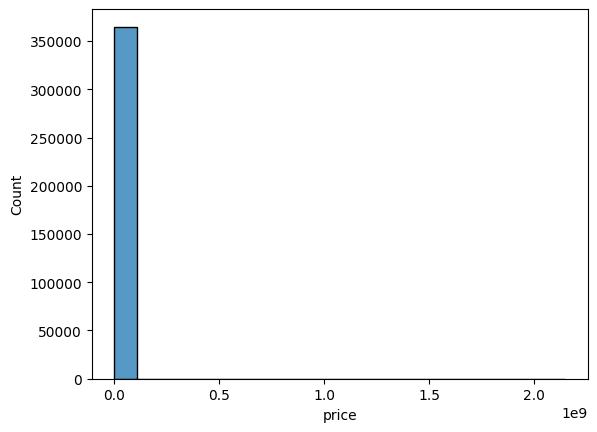

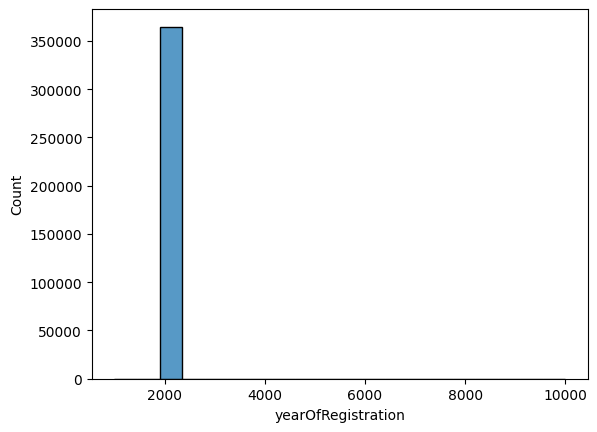

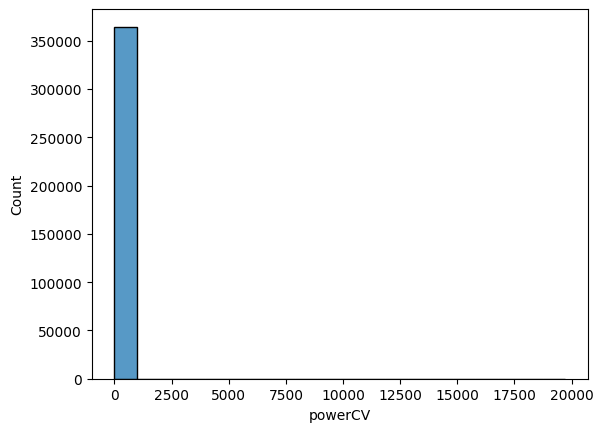

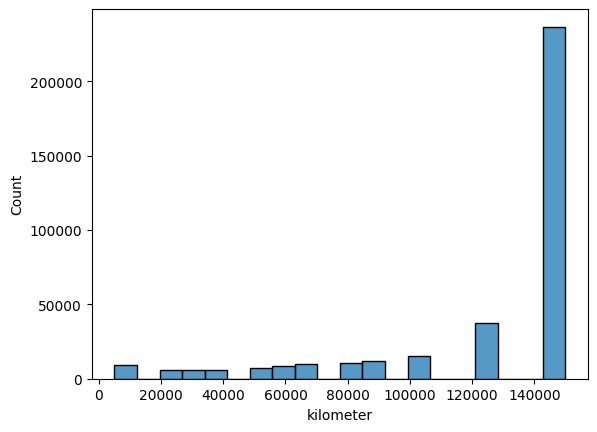

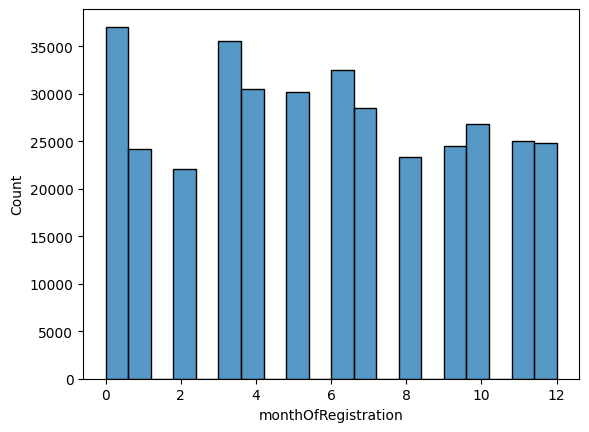

In [17]:
for col in columnas_num:

    plt.figure()
    sns.histplot(df[col], bins=20)
    plt.show()

## Boxplot

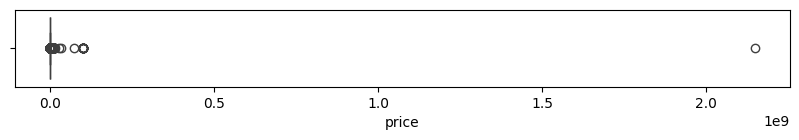

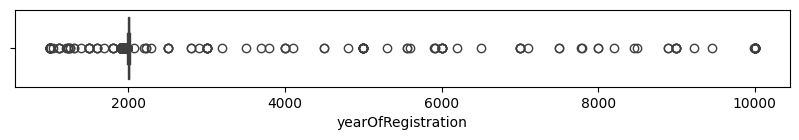

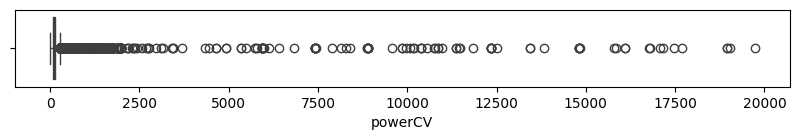

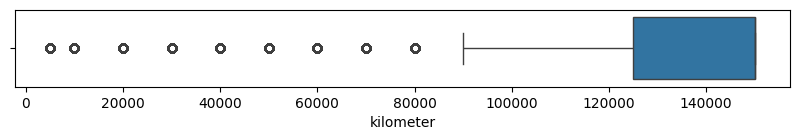

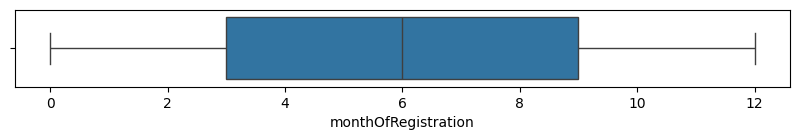

In [18]:
for col in columnas_num:

    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df[col])
    plt.show()

## Columnas categóricas

In [19]:
df.describe(include=['category', 'object']).T

,count,unique,top,freq
name,364904,233531,Ford_Fiesta,650
seller,364904,2,private,364901
offerType,364904,2,offer,364892
vehicleType,233442,7,small car,78621
gearbox,345098,2,manually,269737
model,344610,251,golf,29539
fuelType,331820,7,petrol,220299
brand,364904,40,volkswagen,78227
notRepairedDamage,294128,2,no,258291


In [20]:
columnas_cat = df.select_dtypes(include=['category', 'object']).columns

columnas_cat

Index(['name', 'seller', 'offerType', 'vehicleType', 'gearbox', 'model',
       'fuelType', 'brand', 'notRepairedDamage'],
      dtype='object')

In [21]:
#df['brand'].value_counts()#.head(10)
#df['brand'].nunique() o df['brand'].nunique()

for col in columnas_cat:
    print(f"La columna {col} tiene un total de {df[col].nunique()} valores distintos:")
    print("Los 10 valores más repetidos son:")
    display(df[col].value_counts(dropna=False).head(10))

La columna name tiene un total de 233531 valores distintos:
Los 10 valores más repetidos son:


name
Ford_Fiesta            650
BMW_318i               623
Opel_Corsa             614
Volkswagen_Golf_1.4    598
BMW_316i               515
BMW_320i               490
Volkswagen_Polo        471
Renault_Twingo         444
Volkswagen_Golf        427
Volkswagen_Golf_1.6    411
Name: count, dtype: int64

La columna seller tiene un total de 2 valores distintos:
Los 10 valores más repetidos son:


seller
private       364901
commercial         3
Name: count, dtype: int64

La columna offerType tiene un total de 2 valores distintos:
Los 10 valores más repetidos son:


...

fuelType
petrol     220299
diesel     105088
NaN         33084
lpg          5287
cng           561
hybrid        275
other         207
electro       103
Name: count, dtype: int64

La columna brand tiene un total de 40 valores distintos:
Los 10 valores más repetidos son:


brand
volkswagen       78227
bmw              39567
opel             39359
mercedes_benz    34681
audi             32144
ford             25092
renault          17651
peugeot          10805
fiat              9511
seat              6908
Name: count, dtype: int64

La columna notRepairedDamage tiene un total de 2 valores distintos:
Los 10 valores más repetidos son:


notRepairedDamage
no     258291
NaN     70776
yes     35837
Name: count, dtype: int64

### Countplot

La columna name tiene demasiadas categorías: 233531


Distribución de la columna seller:


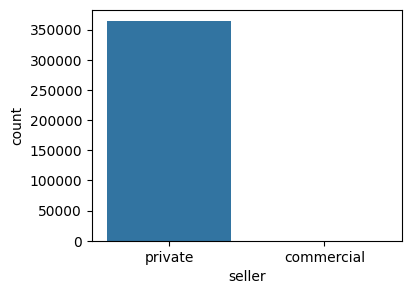

Distribución de la columna offerType:


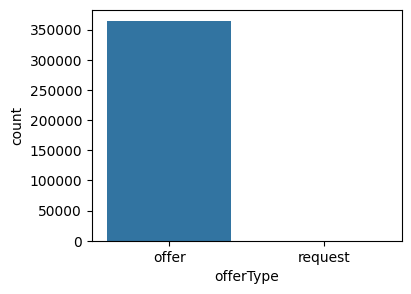

Distribución de la columna vehicleType:


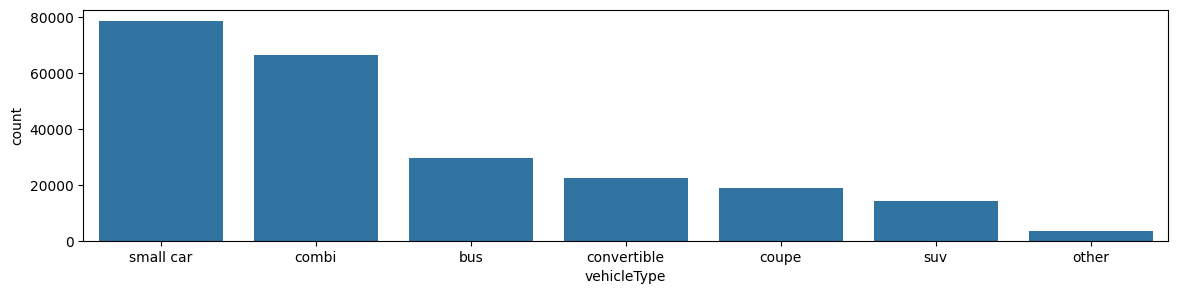

Distribución de la columna gearbox:


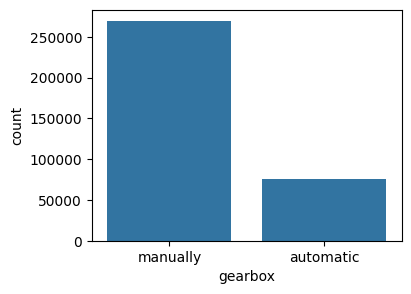

La columna model tiene demasiadas categorías: 251


Distribución de la columna fuelType:


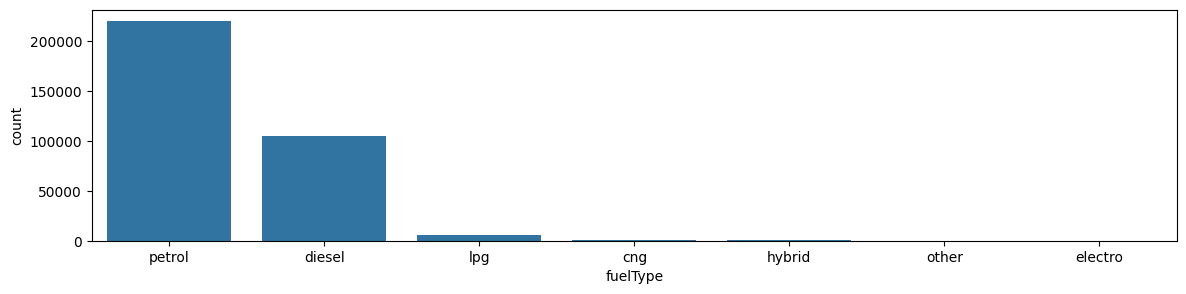

Distribución de la columna brand:


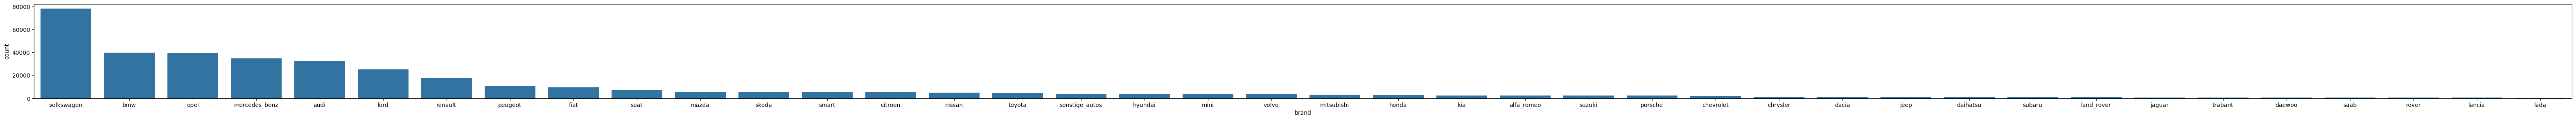

Distribución de la columna notRepairedDamage:


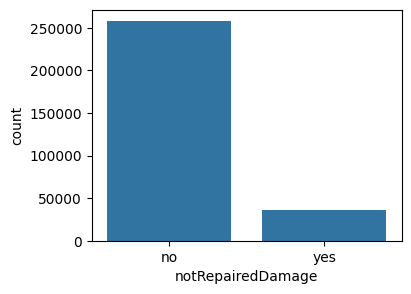

In [32]:
for col in columnas_cat:

    if df[col].nunique() > 200: #si es mayor no muestro grafico
        
    #if col == 'name':
        print(f"La columna {col} tiene demasiadas categorías: {df[col].nunique()}\n\n")
        continue
    print(f"Distribución de la columna {col}:")
    plt.figure(figsize=(df[col].nunique() * 2, 3))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.show()
  